# III. Obliczenie expected exposure (EE) dla FX Forward

## Importy

In [99]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import datetime
import os
from io import StringIO
import yfinance as yf

## Dane Rynkowe

- wczytujemy kurs EUR/PLN ze Stooq (obliczenie zmienności)
- dane rynkowe z pliku otrzymanego na zajęciach

In [100]:
# dane rynkowe
file_path = "https://raw.githubusercontent.com/Sztosik08/FX-Forward-Expected-Exposure-Calculation/main/Dane-rynkowe.xlsx"


import pandas as pd

df = yf.download("EURPLN=X", start="2025-01-01", end="2025-12-31", interval="1d")


df = df[['Close']].copy()
df.index.name = 'Date'
df.columns = ['EURPLN']
df = df.reset_index()
df['Date'] = pd.to_datetime(df['Date'])
df = df.dropna()
print(df.tail)

/tmp/ipykernel_25613/4272296589.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("EURPLN=X", start="2025-01-01", end="2025-12-31", interval="1d")
[*********************100%***********************]  1 of 1 completed

<bound method NDFrame.tail of           Date   EURPLN
0   2025-01-02  4.27345
1   2025-01-03  4.27040
2   2025-01-06  4.26716
3   2025-01-07  4.24840
4   2025-01-08  4.25580
..         ...      ...
251 2025-12-23  4.21435
252 2025-12-24  4.22003
253 2025-12-26  4.21306
254 2025-12-29  4.21209
255 2025-12-30  4.22270

[256 rows x 2 columns]>


Liczymy zmienność (zannualizowaną)

$$\hat{\sigma} = \sqrt{\frac{252}{n-1} \sum_{i=1}^{n} \left( \ln \frac{S_i}{S_{i-1}} - \bar{r} \right)^2}$$

In [101]:
df['log_return'] = np.log(df['EURPLN'] / df['EURPLN'].shift(1))
df = df.dropna()
sigma = df['log_return'].std() * np.sqrt(252)
print(f"{(sigma * 100).round(5)}%")

4.15297%


Dane rynkowe

In [102]:
file_path = "https://raw.githubusercontent.com/Sztosik08/FX-Forward-Expected-Exposure-Calculation/main/Dane-rynkowe.xlsx"

Symulacja Monte Carlo

In [103]:
# Dane rynkowe
df = pd.read_excel(file_path, sheet_name="Arkusz1")
df = df[df['Month'].notna()].copy()

months = df['Month'].astype(int).values
EUR_DF = df['EUR_DF'].astype(float).values
PLN_DF = df['PLN_DF'].astype(float).values
FX_FWD = df['EUR/PLN'].astype(float).values
S0 = float(df['EUR/PLN'].iloc[0])

# parametry
notional = 1_000_000
K = 4.4439 # strike PLN/EUR w 36
T_idx = int(np.where(months == 36)[0][0]) # maturity = 36)
n_steps = T_idx # 36 kroków
dt = 1 / 12
n_sim = 10_000

r_eur = 0.02
r_pln = 0.0375
mu = r_pln - r_eur

Generowanie 10k kursów walutowych

In [104]:
np.random.seed(42)
S = np.zeros((n_sim, n_steps + 1))
S[:, 0] = S0

for t in range(1, n_steps + 1):
    Z = np.random.normal(0.0, 1.0, n_sim)
    S[:, t] = S[:, t-1] * np.exp(
        (mu - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * Z
    )

time_grid = months[:T_idx + 1] / 12

Wycena w każdym kroku symulacji

$$V(t) = N_{EUR} \cdot \left[ F(t, T) - K \right] \cdot DF_{PLN}(t, T)$$

gdzie:

$$F(t, T) = S(t) \cdot \frac{DF_{EUR}(t, T)}{DF_{PLN}(t, T)}$$

$$DF_{x}(t, T) = \frac{DF_{x}(0, T)}{DF_{x}(0, t)}, \quad x \in \{EUR, PLN\}$$

- $N_{EUR}$ — nominał kontraktu (EUR),
- $S(t)$ — symulowany kurs EUR/PLN w momencie $t$,
- $F(t,T)$ — kurs forward w momencie $t$ na datę zapadalności $T$,
- $K$ — kurs wykonania (strike),
- $DF_{x}(t,T)$ — czynnik dyskontowy w walucie $x$ z $t$ do $T$.


In [105]:
V = np.zeros_like(S)
for t in range(n_steps + 1):
    DF_EUR_t_T = EUR_DF[T_idx] / EUR_DF[t]
    DF_PLN_t_T = PLN_DF[T_idx] / PLN_DF[t]
    F_t_T = S[:, t] * DF_EUR_t_T / DF_PLN_t_T
    V[:, t] = notional * (F_t_T - K) * DF_PLN_t_T

$$EE(t) = \mathbb{E}\left[ \max\bigl(V(t), 0\bigr) \right] \approx \frac{1}{M} \sum_{j=1}^{M} \max\bigl(V^{(j)}(t), 0\bigr)$$

In [106]:
pos_exposure = np.maximum(V, 0.0)

EE = pos_exposure.mean(axis=0) # Expected Exposure
PFE_95 = np.percentile(pos_exposure, 95, axis=0)

In [107]:
idx_report = [i for i, m in enumerate(months[:T_idx+1]) if m % 6 == 0]
report = pd.DataFrame({
    'Month': months[idx_report],
    'Time (y)': time_grid[idx_report].round(2),
    'E[S(t)]': S[:, idx_report].mean(axis=0).round(4),
    'Fwd(0,t) mkt': FX_FWD[idx_report].round(4),
    'EE (PLN)': EE[idx_report].round(2),
    'PFE 95% (PLN)': PFE_95[idx_report].round(2),
})

print("profil exposure - co 6 miesięcy")
print(report.to_string(index=False))

profil exposure - co 6 miesięcy
 Month  Time (y)  E[S(t)]  Fwd(0,t) mkt  EE (PLN)  PFE 95% (PLN)
     0       0.0   4.2166        4.2166      0.00           0.00
     6       0.5   4.2536        4.2537  47600.63      197729.81
    12       1.0   4.2924        4.2910  68809.89      288111.25
    18       1.5   4.3306        4.3288  86601.77      360774.03
    24       2.0   4.3679        4.3668 100986.42      421533.70
    30       2.5   4.4054        4.4052 114248.38      484320.45
    36       3.0   4.4426        4.4439 126423.03      546808.16


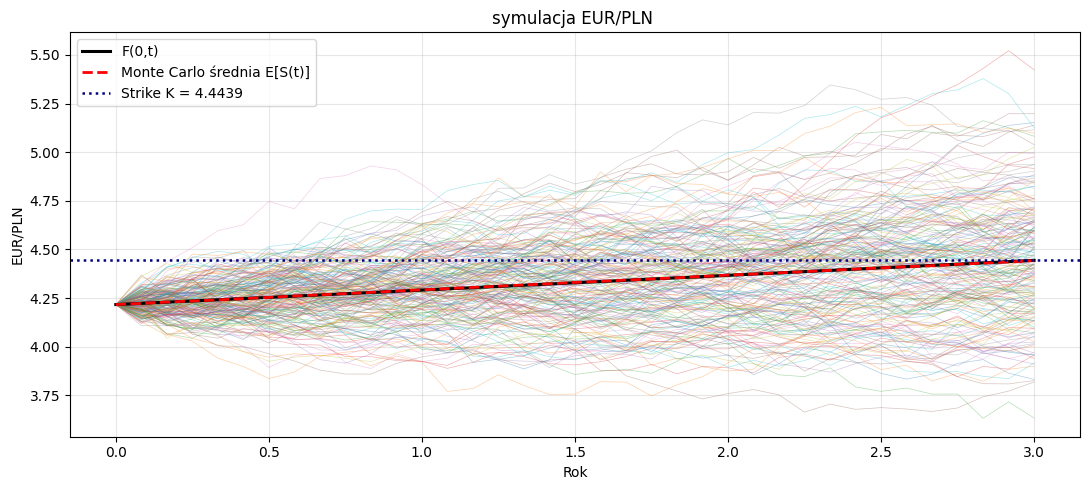

In [108]:
fig, ax = plt.subplots(figsize=(11, 5))

# Monte Carlo - pokazujemy tylko 200
sample_idx = np.random.choice(n_sim, 200, replace=False)
for i in sample_idx:
    ax.plot(time_grid, S[i, :], linewidth=0.5, alpha=0.35)
ax.plot(time_grid, FX_FWD[:T_idx+1], 'k-',  lw=2.2, label='F(0,t)')
ax.plot(time_grid, S.mean(axis=0),  'r--', lw=2.0, label='Monte Carlo średnia E[S(t)]')
ax.axhline(K, color='navy', ls=':', lw=1.8, label=f'Strike K = {K}')
ax.set_title(f'symulacja EUR/PLN ')
ax.set_xlabel('Rok')
ax.set_ylabel('EUR/PLN')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

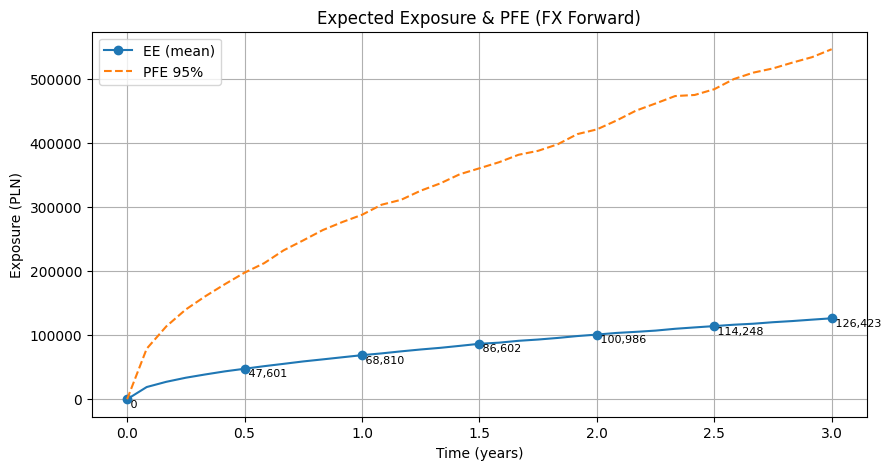

In [109]:
plt.figure(figsize=(10,5))
plt.plot(time_grid, EE, label='EE (mean)', marker='o', markevery=6)
plt.plot(time_grid, PFE_95, label='PFE 95%', linestyle='--')

for i in range(0, T_idx+1, 6):
    plt.text(time_grid[i], EE[i], f' {EE[i]:,.0f}', fontsize=8, va='top')

plt.legend()
plt.title("Expected Exposure & PFE (FX Forward)")
plt.xlabel("Time (years)")
plt.ylabel("Exposure (PLN)")
plt.grid()
plt.show()

In [110]:
# Co 6 miesięcy
indices = [i for i, m in enumerate(months) if m % 6 == 0]

table = pd.DataFrame({
    'Month': months[indices],
    'Time (years)': time_grid[indices],
    'EE (PLN)': EE[indices].round(2),
    'PFE 95% (PLN)': PFE_95[indices].round(2)
})

print(table.to_string(index=False))

 Month  Time (years)  EE (PLN)  PFE 95% (PLN)
     0           0.0      0.00           0.00
     6           0.5  47600.63      197729.81
    12           1.0  68809.89      288111.25
    18           1.5  86601.77      360774.03
    24           2.0 100986.42      421533.70
    30           2.5 114248.38      484320.45
    36           3.0 126423.03      546808.16


In [111]:
# Sanity checks
print(f"EE(0) = {EE[0]:.4f}  powinno być równe 0 na samym początku")
print(f"Max EE = {EE.max():.2f} w miesiącu {months[EE.argmax()]}")
print(f"średnie F(t,T) w t=0 = {(S[:,0] * EUR_DF[T_idx]/PLN_DF[T_idx]).mean():.4f}   "
      f"(powinno być równie eur/pln strike: K = {K})")
print(f"średni kurs eur/pln = {S[:, T_idx].mean():.4f}   "
      f"(powinien być zbliżony do Fwd(0,T) = {FX_FWD[T_idx]:.4f})")

EE(0) = 0.0000  powinno być równe 0 na samym początku
Max EE = 126423.03 w miesiącu 36
średnie F(t,T) w t=0 = 4.4439   (powinno być równie eur/pln strike: K = 4.4439)
średni kurs eur/pln = 4.4426   (powinien być zbliżony do Fwd(0,T) = 4.4439)
